# Insurance Charges - Data Preprocessing

This notebook covers all preprocessing steps to prepare the dataset for modelling.  
Scaling and train-test split are done at the end and saved separately for the modelling notebook.

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('../data/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Cleaning

In [3]:
data_cleaned = data.copy()
data_cleaned.shape

(1338, 7)

In [4]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:

data_cleaned.drop_duplicates(inplace=True)
data_cleaned.shape

# one row deleted which was a duplicated one

(1337, 7)

In [6]:
# check categorical columns for typos or inconsistent labels
for col in ['sex', 'smoker', 'region']:
    print(data_cleaned[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [7]:
#all columns are clean and well formatted, doesnt have any typos or non uniform format

## 3. Outlier Detection & Treatment

Outliers were identified visually in the EDA boxplots for `bmi` and `charges`.  

**Method: IQR Capping**  
Values beyond the IQR fences are replaced with the fence value, the row is preserved, the extreme value is controlled.

```
Lower fence = Q1 - 1.5 × IQR  
Upper fence = Q3 + 1.5 × IQR
```

We cap rather than delete because deleting loses a real patient's entire row of data.

In [8]:
cols_to_cap = ['bmi', 'charges']

for col in cols_to_cap:
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_min = data_cleaned[col].min()
    before_max = data_cleaned[col].max()

    data_cleaned[col] = data_cleaned[col].clip(lower, upper)

    print(f"{col:10s} | Before: [{before_min:.2f} — {before_max:.2f}] "
          f"| After: [{data_cleaned[col].min():.2f} — {data_cleaned[col].max():.2f}]")

bmi        | Before: [15.96 — 53.13] | After: [15.96 — 47.32]
charges    | Before: [1121.87 — 63770.43] | After: [1121.87 — 34524.78]


Text(0.5, 1.0, 'BMI after Capping')

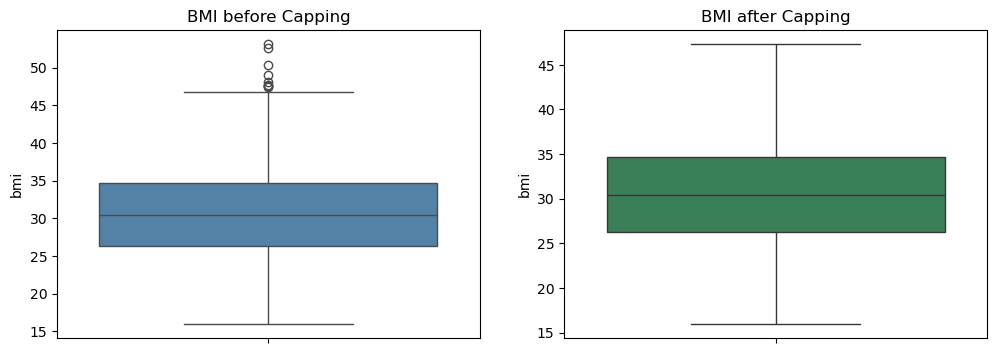

In [9]:
# Visual confirmation - dots above upper whisker should disappear after capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data['bmi'], ax=axes[0], color='steelblue')
axes[0].set_title('BMI before Capping')

sns.boxplot(data_cleaned['bmi'], ax=axes[1], color='seagreen')
axes[1].set_title('BMI after Capping')

## 4. Feature Engineering & Encoding
All categorical columns are converted to numbers.

### 4.1 Label Encoding for Binary Columns
Works only for exactly two categories with no implied order.

In [10]:

data_cleaned['sex'] = data_cleaned['sex'].map({'male': 0, 'female': 1})
data_cleaned.rename(columns={'sex': 'is_female'}, inplace=True)
data_cleaned.head()


,age,is_female,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [11]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'yes': 1, 'no': 0})
data_cleaned.rename(columns={'smoker': 'is_smoker'}, inplace=True)

data_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


### 4.2 One-Hot Encoding for Region
  
One-Hot Encoding creates one binary column per category.

`drop_first=True` drops one column to avoid the **Dummy Variable Trap**, where one column is always predictable from the others. The dropped category becomes the reference (northeast).

In [12]:
data_cleaned = pd.get_dummies(data_cleaned, columns=['region'], drop_first=True, dtype=int)
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


### 4.3 Feature Engineering for BMI Category

Raw `bmi` is a continuous number. The model doesn't inherently know that crossing BMI=30 means "obese."  
Binning into WHO medical categories creates a cleaner signal for threshold effects..

In [13]:
data_cleaned['bmi_category'] = pd.cut(
    data_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

data_cleaned = pd.get_dummies(data_cleaned, columns=['bmi_category'], drop_first=True, dtype=int)
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0


## 5. Target Variable Analysis 

`charges` is right-skewed(we saw in the histogram). Most regression models assume a near-normal target distribution.  
High skew causes extreme values to dominate the squared-error loss function.

`log_charges = ln(charges)` compresses large values, pulling the tail inward.  
The original `charges` column is kept. `log_charges` is the modeling target.  
Predictions are converted back with `np.exp()` at evaluation time.

<Axes: xlabel='log_charges', ylabel='Count'>

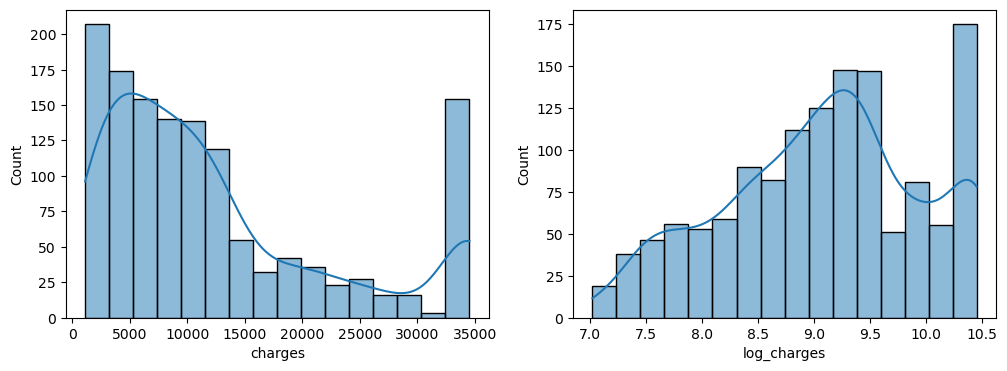

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data_cleaned['charges'], kde=True, ax=axes[0])
data_cleaned['log_charges'] = np.log(data_cleaned['charges'])
sns.histplot(data_cleaned['log_charges'], kde=True, ax=axes[1])

## 6. Save Processed Data

In [15]:
if 'charges_bin' in data_cleaned.columns:
    data_cleaned.drop(columns=['charges_bin'], inplace=True)

In [16]:
data_cleaned.to_csv('../data/insurance_processed.csv', index=False)
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,log_charges
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0,9.734176
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1,7.453302
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1,8.400538
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0,9.998092
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0,8.260197


## 7. Train-Test Split & Feature Scaling

### Why split before scaling?
The scaler learns μ and σ (mean and standard deviation) from the data it's fit on.  
If fit on the full dataset, it incorporates test row statistics into the scaling causing data leakage.  
Test rows are supposed to be completely unseen until evaluation.

**Split → fit scaler on train only → transform both**

In [17]:
# Define features (X) and target (y)
# Drop: charges (raw target), log_charges (we use this as y separately)
cols_to_drop = ['charges', 'log_charges']

X = data_cleaned.drop(columns=cols_to_drop)
y = data_cleaned['log_charges']   # log-transformed target for modeling

print("Feature matrix shape:", X.shape)
print("Target shape:        ", y.shape)
print("Features:", X.columns.tolist())

Feature matrix shape: (1337, 11)
Target shape:         (1337,)
Features: ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")

Training rows: 1069
Test rows:     268


In [19]:
# Fit scaler ONLY on training data
numeric_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])  # learns + applies
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])       # only applies

print("Scaling complete.")
print(f"Scaler mean (age, bmi, children): {scaler.mean_.round(3)}")
print(f"Scaler std  (age, bmi, children): {scaler.scale_.round(3)}")

Scaling complete.
Scaler mean (age, bmi, children): [39.198 30.525  1.084]
Scaler std  (age, bmi, children): [13.992  6.     1.194]


## 8. Save Model-Ready Data

Save the split, scaled data and the scaler object separately.  
The scaler object is critical — it stores the μ and σ from training.  
When predicting on new patients later, you load this scaler and apply it to ensure consistent scaling.

In [20]:
# Save feature matrices and targets
X_train.to_csv('../data/model_ready/X_train.csv', index=False)
X_test.to_csv('../data/model_ready/X_test.csv',   index=False)
y_train.to_csv('../data/model_ready/y_train.csv', index=False)
y_test.to_csv('../data/model_ready/y_test.csv',   index=False)


## Preprocessing Summary

| Step | Action | Result |
|---|---|---|
| Duplicates | drop_duplicates() | 1 row removed → 1,337 rows |
| Missing values | isnull().sum() | None found |
| Outliers | IQR capping on bmi, charges | Extreme values bounded |
| Label encoding | sex → is_female, smoker → is_smoker | 2 binary columns |
| OHE | region → 3 columns (drop_first) | northeast as reference |
| BMI binning | pd.cut() + OHE (drop_first) | 3 medical category columns |
| Log transform | log_charges = ln(charges) | Skewness 1.5 → ~0.2 |
| Split | 80/20 train-test, random_state=42 | 1,070 train / 267 test |
| Scaling | StandardScaler fit on train only | age, bmi, children standardised |

